# 04 · Topic Modeling — BERTopic on Captions & Justifications

Uses **BERTopic** to extract latent topics from annotator captions and justifications.

**Research questions**
- What are the dominant topics annotators address when describing urban scenes?
- Do topics differ by predicted sentiment label?
- Do different persona groups emphasize different topics?

**Pipeline**: `sentence-transformers/all-MiniLM-L6-v2` → UMAP → HDBSCAN → c-TF-IDF (BERTopic)

In [1]:
import sys
sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path

from src.config import FIGURES, OUTPUTS, FONT_SCALE, SENT_COLORS, SENT_COLORS_3
from src.data_loading import load_annotations, parse_demographics, create_profiles
from src.embeddings import load_or_encode_with_ids
from src.topic_modeling import fit_bertopic, topic_sentiment_composition, save_topic_assignments

MUTED = sns.color_palette("muted")
sns.set_theme(style="whitegrid", font_scale=FONT_SCALE)
plt.rcParams["figure.dpi"] = 150

FIGURES.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

df = load_annotations()
df = parse_demographics(df)
df = create_profiles(df)
print(f"Records: {len(df):,} | Images: {df['image_id'].nunique():,} | Personas: {df['persona_id'].nunique():,}")

Records: 59,708


## 1 · Encode texts (reuse or compute embeddings)

In [2]:
CAPTION_EMBED_CACHE = OUTPUTS / "caption_embeddings.npy"
JUST_EMBED_CACHE    = OUTPUTS / "justification_embeddings.npy"
ID_CACHE            = OUTPUTS / "caption_embeddings_ids.csv"

cap_embs,  cap_idx  = load_or_encode_with_ids(df, "caption",       CAPTION_EMBED_CACHE, ID_CACHE)
just_embs, just_idx = load_or_encode_with_ids(df, "justification", JUST_EMBED_CACHE,    ID_CACHE)
print(f"Caption embeddings:       {cap_embs.shape}")
print(f"Justification embeddings: {just_embs.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded caption embeddings: (59708, 384)
Loaded justification embeddings: (59708, 384)


## 2 · Fit BERTopic on captions

In [3]:
CAPTION_TOPIC_CACHE = OUTPUTS / "bertopic_captions.pkl"

cap_texts = df["caption"].tolist()
topic_model_captions, cap_topics, cap_probs = fit_bertopic(cap_texts, cap_embs)
df["caption_topic"] = cap_topics
print(f"Caption topics: {len(set(cap_topics)) - 1} topics + noise")

2026-04-27 15:58:05,384 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


/mnt/raid5/neemias/percepta-urbana/.venv/lib/python3.11/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


2026-04-27 16:06:12,868 - BERTopic - Dimensionality - Completed ✓


2026-04-27 16:06:12,870 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-04-27 16:06:18,094 - BERTopic - Cluster - Completed ✓


2026-04-27 16:06:18,104 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-04-27 16:06:18,896 - BERTopic - Representation - Completed ✓


Topics found in captions: 207 (+1 outlier)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,17977,-1_trees_brick_clear_buildings,"[trees, brick, clear, buildings, stone, sky, v...","[A sunlit park with trees, fallen leaves, and ..."
1,0,1127,0_peeling_lighting_debris floor_abandoned,"[peeling, lighting, debris floor, abandoned, l...","[An abandoned bedroom with peeling wallpaper, ..."
2,1,1053,1_indoor_using_workers_maintenance,"[indoor, using, workers, maintenance, blue, in...",[Workers using shovels to maintain an indoor f...
3,2,1024,2_long_clean_lighting_metal,"[long, clean, lighting, metal, ceiling, walls,...","[A long, empty subway station with clean tiled..."
4,3,889,3_rusted metal_rusted_metal_showing signs,"[rusted metal, rusted, metal, showing signs, s...",[An old stone structure with rusted metal comp...
5,4,705,4_sign_accident_indicating_person,"[sign, accident, indicating, person, bright, p...",[A person operating a tool that emits bright s...
6,5,665,5_space_photograph_black white_black,"[space, photograph, black white, black, deteri...",[A black and white photograph of a deteriorate...
7,6,617,6_window_red_building facade_facade,"[window, red, building facade, facade, dark, f...","[A weathered building facade with a chain, pip..."
8,7,602,7_bare_bare trees_city skyline_skyline,"[bare, bare trees, city skyline, skyline, leaf...",[A view of bare trees and dry vegetation with ...
9,8,601,8_scattered debris_including_car_concrete,"[scattered debris, including, car, concrete, s...","[A highway with scattered debris, including a ..."


## 3 · Top words per caption topic

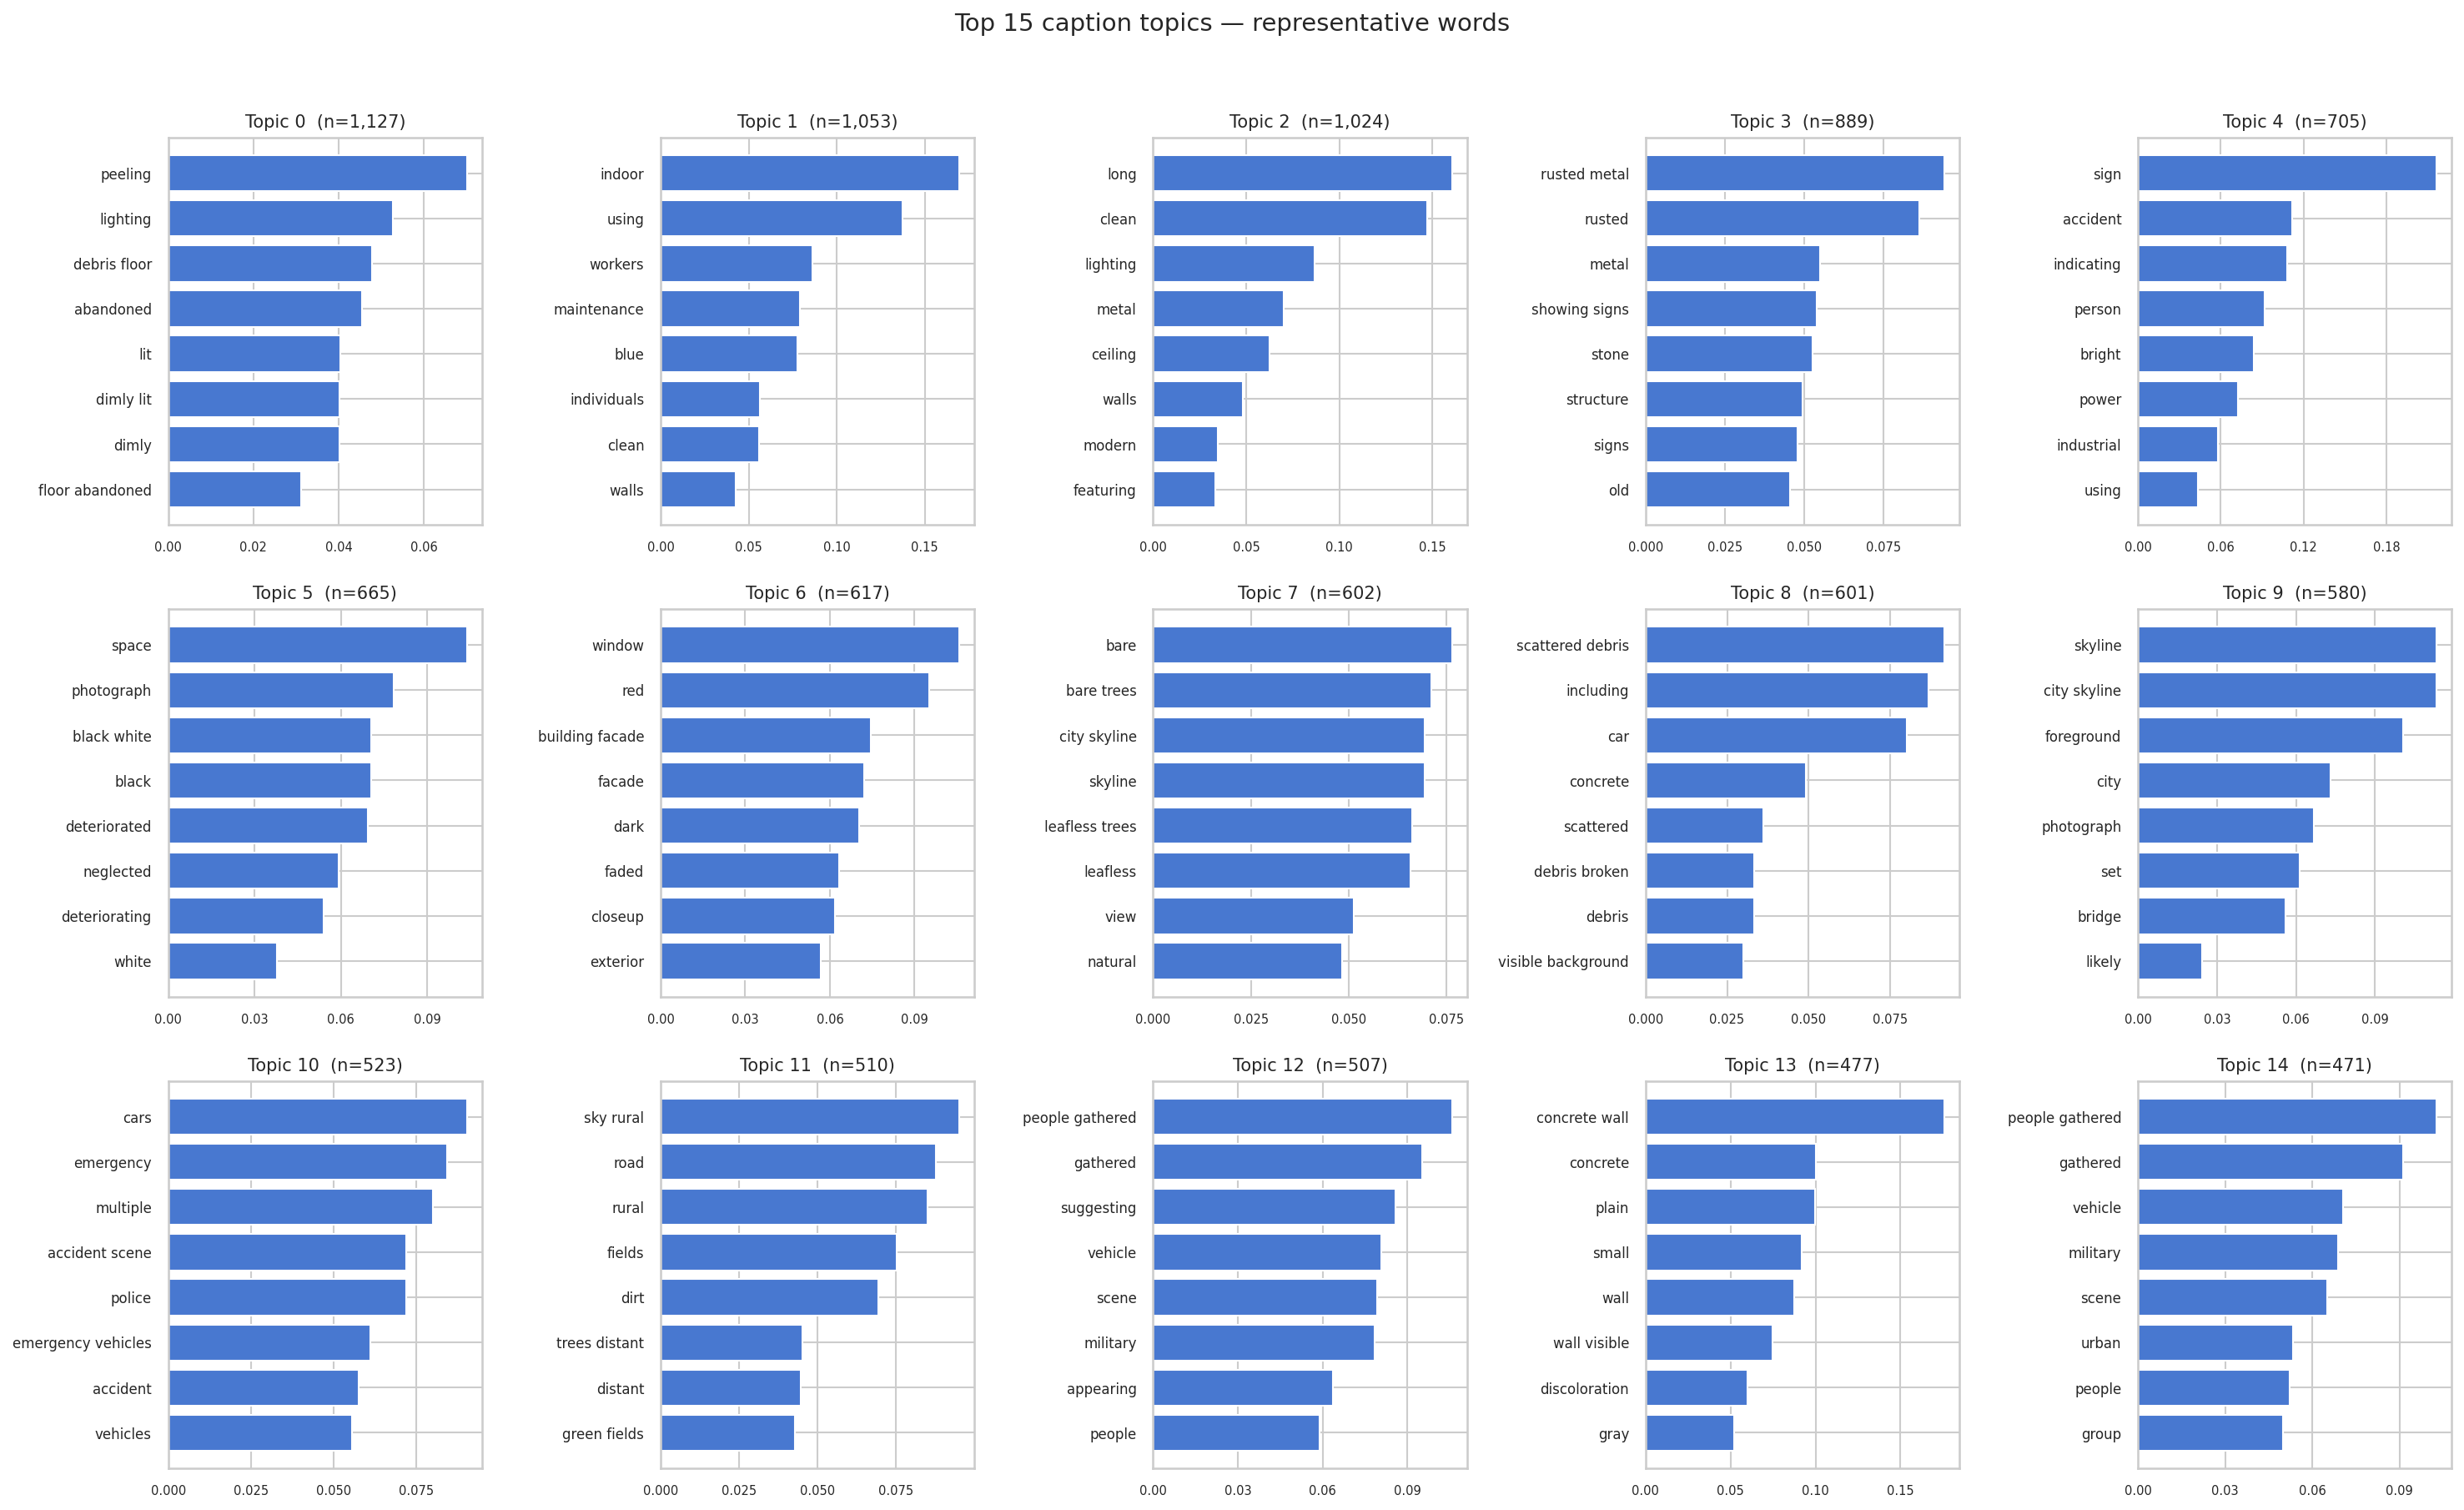

In [4]:
n_show = 15
topic_info = topic_model_captions.get_topic_info()
top_topics = topic_info[topic_info["Topic"] != -1].head(n_show)["Topic"].tolist()

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
for ax, tid in zip(axes.flat, top_topics):
    words, scores = zip(*topic_model_captions.get_topic(tid)[:8])
    ax.barh(list(words)[::-1], list(scores)[::-1], color=MUTED[0])
    count = int(topic_info[topic_info["Topic"] == tid]["Count"].iloc[0])
#     ax.set_title(f"Topic {tid}  (n={count:,})", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=7)
    # prevent x-tick overlap
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))

# plt.suptitle("Top 15 caption topics — representative words", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES / "fig_topic_caption_top15.pdf")
fig.savefig(FIGURES / "fig_topic_caption_top15.png")
plt.show()


## 4 · Fit BERTopic on justifications

In [5]:
just_texts = df["justification"].tolist()
topic_model_just, just_topics, just_probs = fit_bertopic(just_texts, just_embs)
df["just_topic"] = just_topics
print(f"Justification topics: {len(set(just_topics)) - 1} topics + noise")

2026-04-27 16:06:22,639 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-04-27 16:07:48,038 - BERTopic - Dimensionality - Completed ✓


2026-04-27 16:07:48,040 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-04-27 16:07:50,701 - BERTopic - Cluster - Completed ✓


2026-04-27 16:07:50,711 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-04-27 16:07:51,630 - BERTopic - Representation - Completed ✓


Topics found in justifications: 115 (+1 outlier)


,Topic,Count,Name,Representation,Representative_Docs
0,-1,8956,-1_neglect_state_public_space,"[neglect, state, public, space, failure, visib...",[The visible decay and neglect reflect systemi...
1,0,3203,0_natural_landscape_natural setting_beauty,"[natural, landscape, natural setting, beauty, ...",[The serene natural setting and warm sunlight ...
2,1,2368,1_work_essential_development_workers,"[work, essential, development, workers, hard w...",[This image shows dedicated workers contributi...
3,2,2167,2_accident_police_response_situation,"[accident, police, response, situation, vehicl...","[Another accident scene, probably from those r..."
4,3,2097,3_rural_quiet_road_scene,"[rural, quiet, road, scene, traditional, scene...",[This orderly rural scene reflects traditional...
5,4,1199,4_historical_wellpreserved_preserved_emotional,"[historical, wellpreserved, preserved, emotion...",[It's a historical military aircraft on displa...
6,5,1189,5_destruction_conflict_presence_violent,"[destruction, conflict, presence, violent, vio...",[The visible destruction and military presence...
7,6,1178,6_streets_wellmaintained urban_orderly urban_c...,"[streets, wellmaintained urban, orderly urban,...",[The orderly urban landscape with clean street...
8,7,1142,7_city_natural setting_natural_trees,"[city, natural setting, natural, trees, urban,...",[The serene natural setting and distant citysc...
9,8,1104,8_home_peaceful scene_warm_comfort,"[home, peaceful scene, warm, comfort, sunlight...",[The peaceful scene of a cat basking in warm l...


## 5 · Topic distribution by predicted sentiment (justifications)

## 4.5 · Top words per justification topic

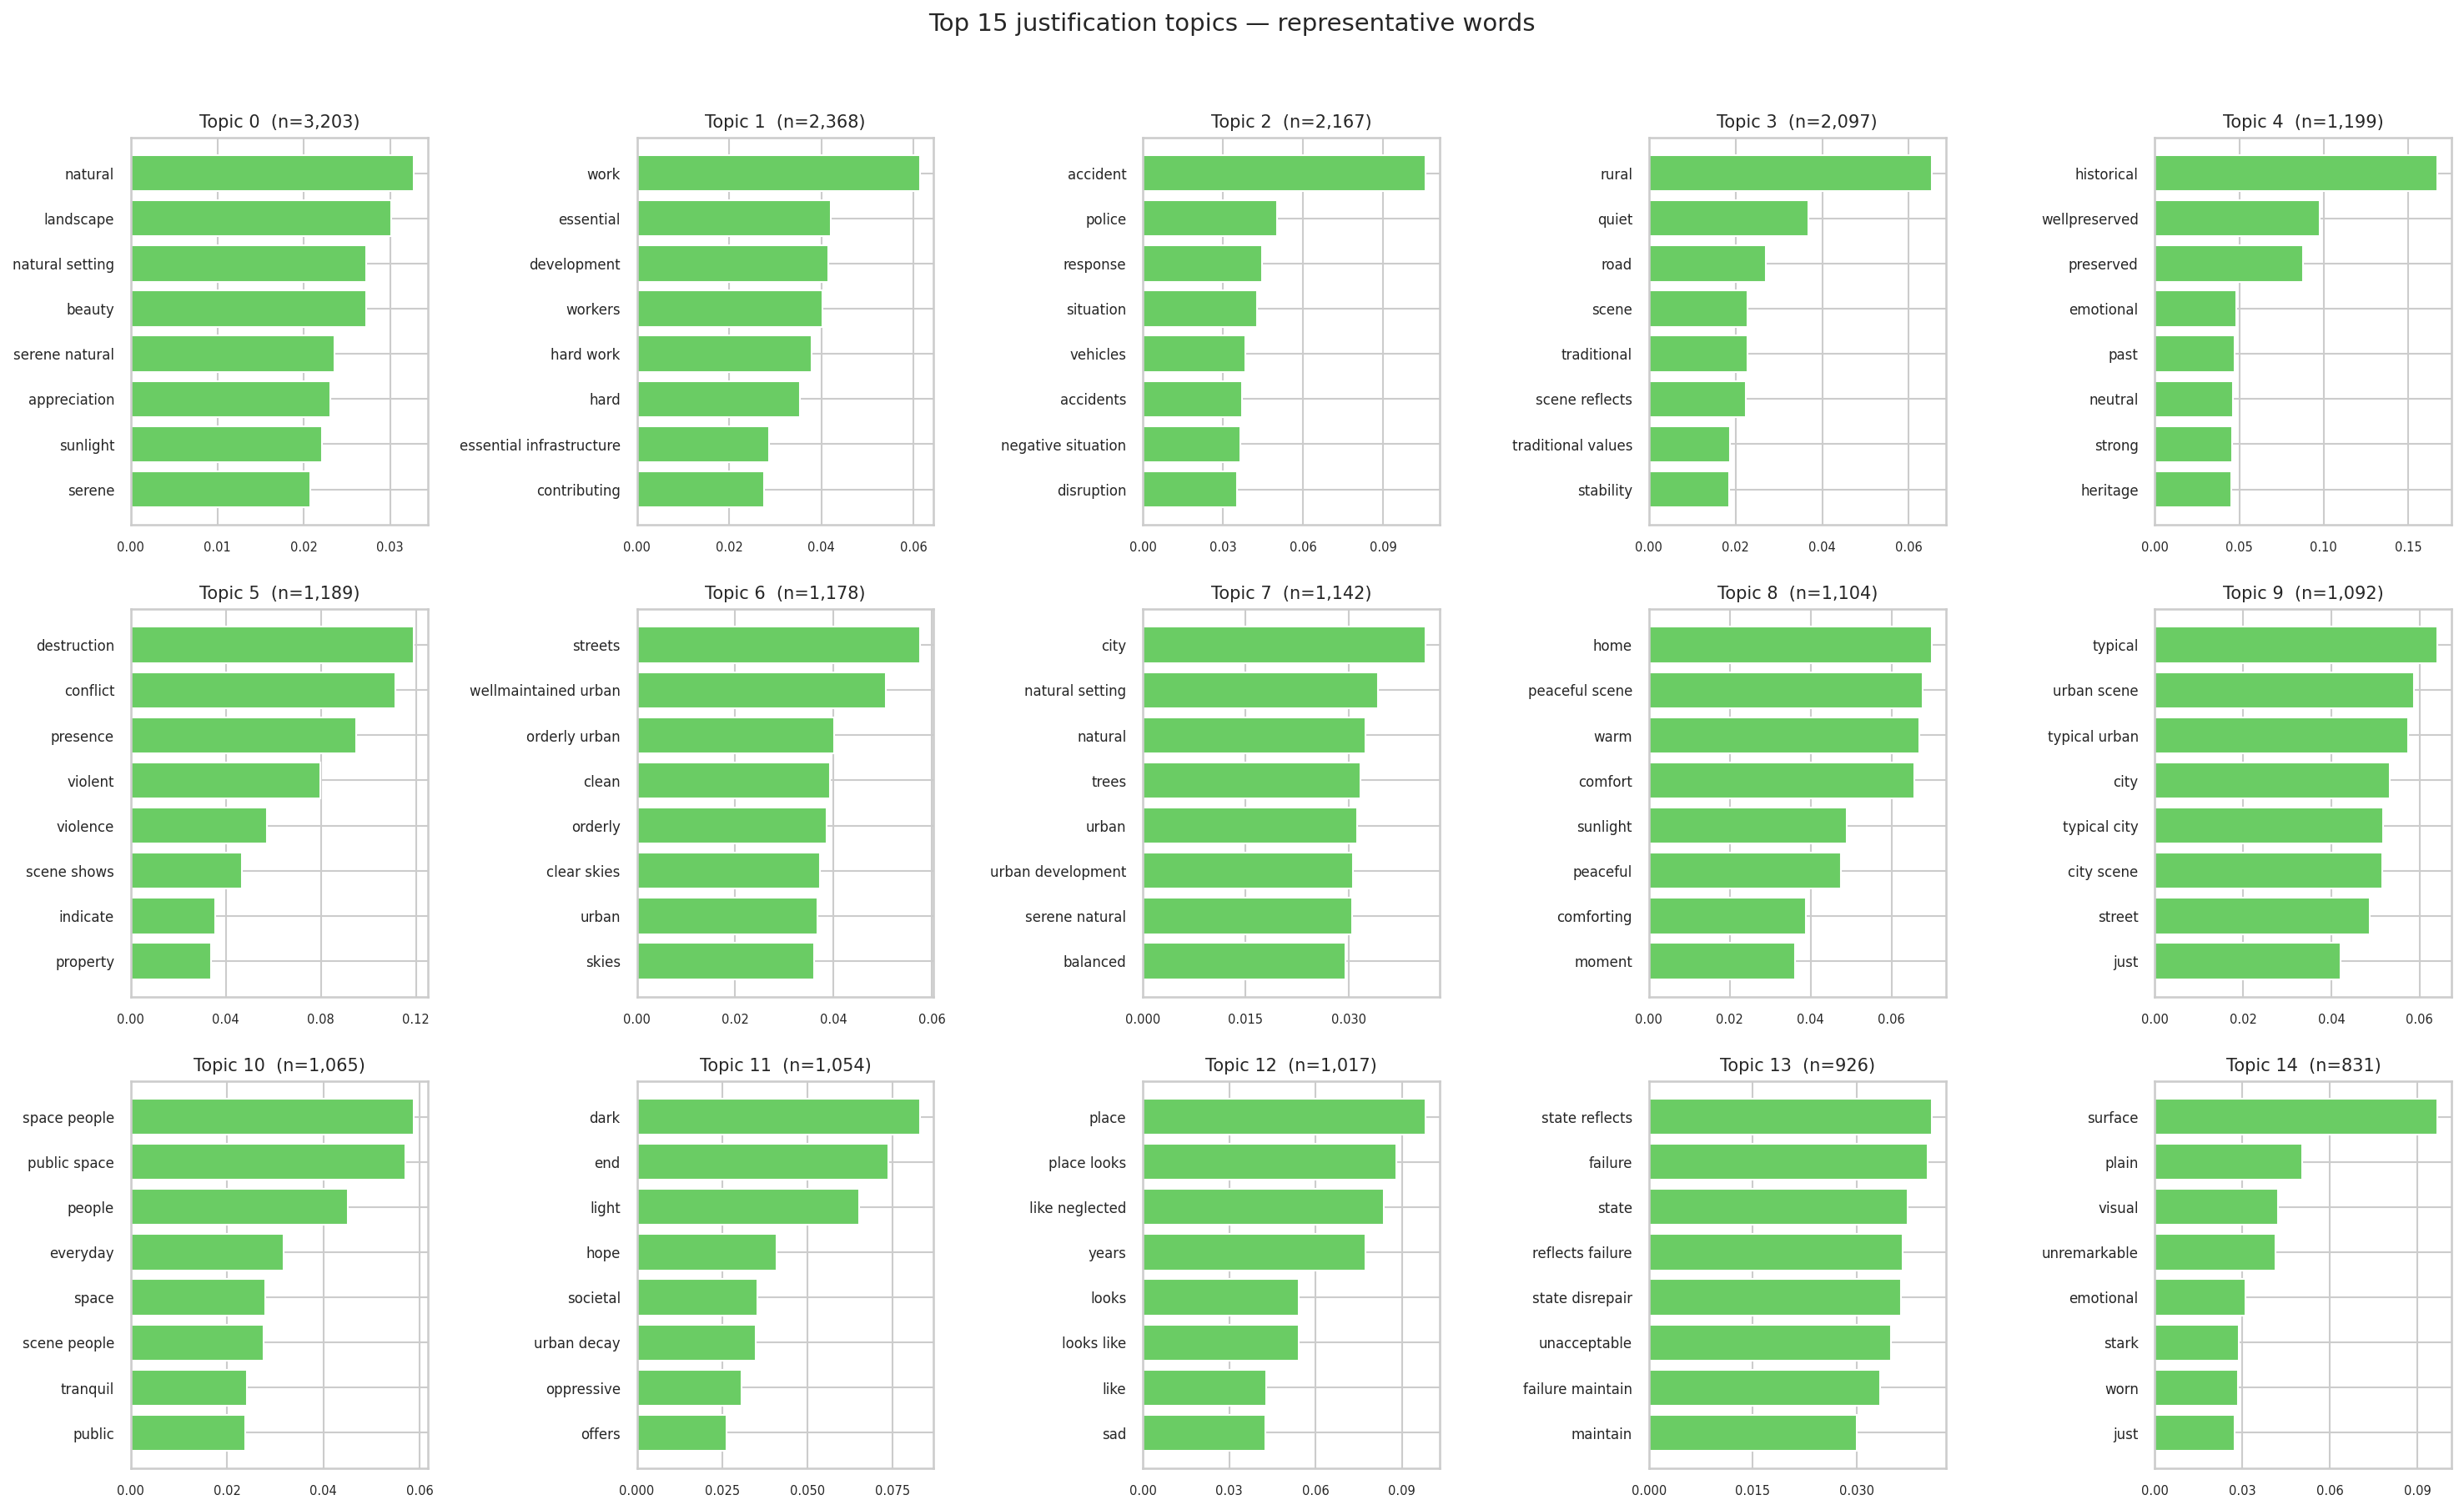

In [6]:
n_show_just = 15
just_topic_info = topic_model_just.get_topic_info()
top_just_show = just_topic_info[just_topic_info["Topic"] != -1].head(n_show_just)["Topic"].tolist()

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
for ax, tid in zip(axes.flat, top_just_show):
    words, scores = zip(*topic_model_just.get_topic(tid)[:8])
    ax.barh(list(words)[::-1], list(scores)[::-1], color=MUTED[2])
    count = int(just_topic_info[just_topic_info["Topic"] == tid]["Count"].iloc[0])
#     ax.set_title(f"Topic {tid}  (n={count:,})", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
    ax.tick_params(axis="x", labelsize=7)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))

# plt.suptitle("Top 15 justification topics — representative words", fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES / "fig_topic_just_top15.pdf")
fig.savefig(FIGURES / "fig_topic_just_top15.png")
plt.show()


In [ ]:
import numpy as np
from matplotlib.ticker import FuncFormatter

# ── Short descriptive labels for the top 10 justification topics ───────────
_TOPIC_LABELS = {
    0: "Natural landscape & beauty",
    1: "Work & development",
    2: "Accident & police response",
    3: "Rural & quiet road",
    4: "Historical & preserved",
    5: "Destruction & conflict",
    6: "Streets & orderly urban",
    7: "City & nature",
    8: "Home & peaceful scene",
    9: "Typical urban scene",
}

just_info = topic_model_just.get_topic_info()
top_just_topics = just_info[just_info["Topic"] != -1].head(10)["Topic"].tolist()

sent_topic = (
    df[
        df["just_topic"].isin(top_just_topics)
        & df["predicted_sentiment"].isin(["Positive", "Neutral", "Negative"])
    ]
    .groupby(["just_topic", "predicted_sentiment"])
    .size()
    .reset_index(name="count")
)

pivot = sent_topic.pivot(
    index="just_topic", columns="predicted_sentiment", values="count"
).fillna(0)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)[["Positive", "Neutral", "Negative"]]
pivot_norm.index = [_TOPIC_LABELS.get(i, str(i)) for i in pivot_norm.index]

# Sort ascending by Negative → least negative at bottom, most negative at top
pivot_norm = pivot_norm.sort_values("Negative", ascending=True)

# ── Plot ───────────────────────────────────────────────────────────────────
COLS   = ["Positive", "Neutral", "Negative"]
COLORS = [SENT_COLORS_3[c] for c in COLS]

fig, ax = plt.subplots(figsize=(9, 5.5))
left = np.zeros(len(pivot_norm))

for col, color in zip(COLS, COLORS):
    vals = pivot_norm[col].values
    ax.barh(range(len(pivot_norm)), vals, left=left,
            color=color, label=col, height=0.62,
            edgecolor="white", linewidth=0.5)
    for i, (val, l) in enumerate(zip(vals, left)):
        if val > 0.09:
            ax.text(l + val / 2, i, f"{val:.0%}",
                    ha="center", va="center", fontsize=9,
                    color="white", fontweight="bold")
    left += vals

ax.set_yticks(range(len(pivot_norm)))
ax.set_yticklabels(pivot_norm.index, fontsize=11)
ax.set_xlabel("Proportion", fontsize=11)
ax.set_xlim(0, 1.0)
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.tick_params(axis="x", labelsize=10)
ax.xaxis.grid(True, linestyle="--", alpha=0.35, color="gray", zorder=0)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
ax.legend(
    title="Sentiment", bbox_to_anchor=(1.01, 0.5), loc="center left",
    fontsize=10, title_fontsize=10, framealpha=0.9,
)

plt.tight_layout()
fig.savefig(FIGURES / "fig_topic_just_sentiment_composition.pdf", bbox_inches="tight")
fig.savefig(FIGURES / "fig_topic_just_sentiment_composition.png", bbox_inches="tight")
plt.show()


## 5b · Topic distribution by predicted sentiment (captions)


In [ ]:
# ── Sentiment composition per caption topic (mirrors justification analysis) ──
sns.set_theme(font_scale=1.4)

cap_info2 = topic_model_captions.get_topic_info()
top_cap_topics2 = cap_info2[cap_info2["Topic"] != -1].head(10)["Topic"].tolist()

sent_topic_cap = (
    df[
        df["caption_topic"].isin(top_cap_topics2)
        & df["predicted_sentiment"].isin(["Positive", "Neutral", "Negative"])
    ]
    .groupby(["caption_topic", "predicted_sentiment"])
    .size()
    .reset_index(name="count")
)

pivot_cap = sent_topic_cap.pivot(
    index="caption_topic", columns="predicted_sentiment", values="count"
).fillna(0)
pivot_cap_norm = pivot_cap.div(pivot_cap.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
pivot_cap_norm[["Positive", "Neutral", "Negative"]].plot(
    kind="bar", stacked=True, ax=ax,
    color=[SENT_COLORS_3["Positive"], SENT_COLORS_3["Neutral"], SENT_COLORS_3["Negative"]],
)
ax.set_xlabel("Caption topic ID")
ax.set_ylabel("Proportion")
ax.legend(title="Predicted sentiment", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.tick_params(axis="x", rotation=0)
for bar_stack in ax.containers:
    ax.bar_label(
        bar_stack,
        fmt=lambda v: f"{v:.0%}" if v > 0.08 else "",
        label_type="center", fontsize=8, color="white", fontweight="bold",
    )
plt.tight_layout()
fig.savefig(FIGURES / "fig_topic_caption_sentiment_composition.pdf")
fig.savefig(FIGURES / "fig_topic_caption_sentiment_composition.png")
plt.show()


## 6 · Save topic assignments

In [8]:
df[["annotation_id", "persona_id", "image_id",
    "predicted_sentiment", "caption_topic", "just_topic"]].to_csv(
    OUTPUTS / "annotations_with_topics.csv", index=False
)

topic_model_captions.get_topic_info().to_csv(OUTPUTS / "caption_topic_info.csv", index=False)
topic_model_just.get_topic_info().to_csv(OUTPUTS / "just_topic_info.csv", index=False)
print("Saved topic assignments and topic info.")

Saved topic assignments and topic info.


## 7 · Topic × Persona profile heatmaps

For each of the top 15 topics (captions and justifications separately),
compute what proportion of each persona profile's annotations are assigned to that topic.
Column-normalized: reveals differential topic usage across persona groups.


In [ ]:
import json as _jj
import ast as _at3

# Load topic assignments + join demographics
_tdf = pd.read_csv(OUTPUTS / "annotations_with_topics.csv")
_mdf = _tdf.merge(df[["annotation_id", "profile_abbr"]], on="annotation_id", how="left")

_tp_pivots = {}
for _modality, _tcol, _info_csv in [
    ("caption", "caption_topic", OUTPUTS / "caption_topic_info.csv"),
    ("just",    "just_topic",    OUTPUTS / "just_topic_info.csv"),
]:
    _ti   = pd.read_csv(_info_csv)
    _top  = _ti[_ti["Topic"] != -1].head(15)["Topic"].tolist()
    _tp   = (
        _mdf[_mdf[_tcol].isin(_top)]
        .groupby([_tcol, "profile_abbr"])
        .size()
        .reset_index(name="count")
    )
    _piv   = _tp.pivot(index=_tcol, columns="profile_abbr", values="count").fillna(0)
    _piv_n = _piv.div(_piv.sum(axis=0), axis=1)
    _tp_pivots[_modality] = _piv_n
    print(f"{_modality}: pivot shape {_piv_n.shape}")

In [ ]:
sns.set_theme(font_scale=1.4)

def _tp_heatmap(pivot, fname, annot=False):
    fig, ax = plt.subplots(figsize=(18, 7))
    sns.heatmap(
        pivot, ax=ax, cmap="Blues",
        annot=annot, fmt=".2f", annot_kws={"fontsize": 5.5},
        linewidths=0.3, linecolor="white",
        cbar_kws={"label": "Proportion of profile annotations", "shrink": 0.6},
    )
    ax.set_xlabel("Persona profile", fontsize=11)
    ax.set_ylabel("Topic ID", fontsize=11)
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=9)
    plt.tight_layout()
    fig.savefig(FIGURES / f"{fname}.pdf", bbox_inches="tight")
    fig.savefig(FIGURES / f"{fname}.png", bbox_inches="tight")
    plt.show()
    print(f"Saved {fname}")

_tp_heatmap(_tp_pivots["caption"], "fig_topic_persona_heatmap_caption")
_tp_heatmap(_tp_pivots["just"],    "fig_topic_persona_heatmap_just", annot=True)
